# Example Script: Attention map generation

This script will highlight all the steps that can be performed to investigate the attention of the DL model

In this example is the lung cancer patient cohort used to obtain the DL model with given weights

In [59]:
# Imports
%matplotlib inline
%load_ext autoreload
%autoreload 2

# import global libraries
import captum
from captum.attr._utils.input_layer_wrapper import ModelInputWrapper
from captum.attr import (
    IntegratedGradients,
    GuidedBackprop,
    GuidedGradCam,
    #LayerGradCam,
    NoiseTunnel,
    GradientShap,
    Saliency,
    LRP)
from src.visualization.attribution.GradCamPlusPlus import GradCamPlusPlus
from captum.attr import LayerAttribution


import numpy as np
import torch
from torch.utils.data import DataLoader

# Local libraries enivironment loading
import os
import sys
from pathlib import Path
import copy

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Import local libraries
from src.constants import DEVICE
from src.utils.set_random_seed import set_random_seed
from src.models.tools.get_classification_model import get_classification_model
from src.config_presets.tools.get_config import get_config
from src.config_presets.tools.load_config import load_config
from src.dataset.load_dataset import load_dataset
from src.dataset.get_dataloader import make_dataloader   
from src.dataset.get_transforms import get_transforms


### Loading the model and datasets

In [38]:

fold_dir = r"C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\pred_RT_results\Xerostomia_M06\ResNet18\KFold1"
filename_model_weights = "DlModel_Weights.pth"
filename_config = "DlModel_Config.yaml"

# select if the config file is loaded with path or global
config = load_config(os.path.join(fold_dir,"DlModel_Config.yaml")) #get_config('DETOXLung_config')

# Disable randomness
set_random_seed(config['general']['seed'])

# load data
df_train_val, df_test = load_dataset(config)
train_transforms, val_transforms = get_transforms(config)
test_loader, metadata = make_dataloader(config, df_test, val_transforms, validation_mode=True)


pathModelWeigths = os.path.join(fold_dir, filename_model_weights)
model = get_classification_model(config, metadata, False)
model.load_state_dict(torch.load(pathModelWeigths))
print("Successfully loaded model and datasets")

C:\Users\S.P.M. de Vette\OneDrive - UMCG\Desktop\pred_RT_results\Xerostomia_M06\ResNet18\KFold1\DlModel_Config.yaml
Removed patients (no image data) = 0
Train/Val dataset 872 (80.0%), Test dataset 218 (20.0%)


c:\Users\S.P.M. de Vette\.conda\envs\HNC_310\lib\site-packages\torch\nn\modules\lazy.py:181: UserWarning: Lazy modules are a new feature under heavy development so changes to the API or functionality can happen at any moment.
  warnings.warn('Lazy modules are a new feature under heavy development '
c:\Users\S.P.M. de Vette\.conda\envs\HNC_310\lib\site-packages\torch\nn\modules\conv.py:605: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv3d(


Successfully loaded model and datasets


## Wrapping the model in the Captum package's input wrapper

This allows the model to accept multiple inputs (i.e. the clinical features, and not just one array of image features)

In [39]:
DEVICE = torch.device('cuda:0')

# wrap the model with the ModelInputWrapper
model = ModelInputWrapper(model)

model.to(DEVICE)     # send the model to the GPU


ModelInputWrapper(
  (module): MultiTox_Classifier(
    (encoder): ResNet_LReLU(
      (conv1): Conv3d(3, 64, kernel_size=(5, 5, 5), stride=(2, 2, 2), padding=(2, 2, 2), bias=False)
      (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): LeakyReLU(negative_slope=0.1)
      (maxpool): MaxPool3d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (backbone): ModuleList(
        (0): Sequential(
          (0): BasicBlock(
            (conv1): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
            (bn1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (act): LeakyReLU(negative_slope=0.1)
            (conv2): Conv3d(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
            (bn2): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
          (1): BasicBlock(
      

# Applying the attribution map method

You will have to chose a method with which to make the attention maps. Here, I show three of them, but more can be found on the website of the Captum package.
1. **Integrated Gradients**: returns an attention map that is the same size as the input. In other words, you get an attention map for each of the CT, dose, segmentations, and clinical features.
2. **GradientSHAP**: an approximation of the SHAP method, is fairly nice for assessing the importance of the clinical variables (but also works on the image data, I'm just not sure if you can really compare the attention on the clinical variables directly to the attention on the CT)
3. **GuidedGradCam**: this is similar to what Hung and Suzanne have used for the Xerostomia and Dysphagia models (same method, from a different library, as far as I'm aware. They used an adjusted version of the MedCam package). Unlike integrated gradients, this returns a 1 channel array, so you cannot tell the difference between the attentions on the CT or dose, as they are merged. You also have to pick a layer in the model to make attention maps on; thus this is not model agnostic, and means you might have to specifiy different layers if you are making attention maps for different models.


In [6]:
# import global libraries
import captum
import torch.nn.functional as F
from tqdm import tqdm
from captum.attr._utils.input_layer_wrapper import ModelInputWrapper
from captum.attr import (
    IntegratedGradients,
    GuidedBackprop,
    GuidedGradCam,
    LayerGradCam,
    NoiseTunnel,
    GradientShap,
    Saliency,
    LayerLRP,
    )

"""
1. Integrated Gradients
"""
#
#attr = IntegratedGradients(model)
#attr = NoiseTunnel(attr)


"""
2. Gradient SHAP
"""
#attr = GradientShap(model)

"""
3. GuidedGradCam
"""
# features.denseblock_4.denselayer1.layers.conv1
#attr = GuidedGradCam(model, model.module.encoder.backbone.block3[0].conv2) # model.module.encoder.conv1)   # for a DenseNet model     


In [7]:
model.module.encoder.backbone.block3[0]

BasicBlock(
  (conv1): Conv3d(192, 256, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1), bias=False)
  (bn1): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act): LeakyReLU(negative_slope=0.1)
  (conv2): Conv3d(256, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
  (bn2): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (downsample): Sequential(
    (0): Conv3d(192, 256, kernel_size=(1, 1, 1), stride=(2, 2, 2), bias=False)
    (1): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
)

In [72]:
from tqdm import tqdm
# put the model into evaluation mode ! this saves some GPU space
model.eval()

def sigmoid(x):
    return 1/(1+np.exp(-x))

label = "RP_OneYear"
Sigmoid = np.vectorize(sigmoid)
index = 0
indexTarget = 0

attr_maps = []

for data in tqdm(test_loader):
    data
    # Load data, send it to the GPU
    inputs, features, label_list = (
        data['input'].to(DEVICE),
        data['features'].to(DEVICE),
        data['label_list'].to(DEVICE),
        )
    
    if label_list.item() == 0:
        continue
    elif index < 1:
        index+=1
        continue

    # group the image inputs and the feature inputs into a tuple (this for the ModelInputWrapper)
    model_input = torch.tensor(inputs)

    # most methods require a baseline input. This is a fairly important choice, typically it is an array of zeros, but it can also be an array of pure noise or the mean of the dataset
    # these baselines are used to calculate the integral of the gradients, and they can have an effect on how the attention maps look (e.g. an all-zero baseline will lead to attention that highlights the white parts of the CT !)
    baseline_input_randn = torch.randn_like(torch.tensor(inputs))  # random noise input
    baseline_input_zeros = torch.zeros_like(torch.tensor(inputs))  # all zeroes input

    baseline_input_noDose = copy.deepcopy(model_input)
    baseline_input_noDose[0, 1] = 0

    

    # target index is the index of the class that we want to calculate the attention map for (i.e. the index of the value in the model's output tensor)
    # for single-toxicty models, I think it's just 0
    target_idx = 0
    # in Daniel's model code, this additional forward argument is used to make the model output in the shape of a tensor
    # normally the output is a dictionary {"Toxcity_A" : 1234, "Toxicity_B" : 5678, ...}, but for the attention maps, we need a tensor  [of shape (1, num_classes), I think]
    additional_forward_args = (features, True)

    # the number of steps used by the approximation method (for integrated gradients, which uses 50 by default), it seems that more steps = more GPU useage
    n_steps = 100
    batch_size = 1

    """
    For binary classification models:
    """

    # # 
    attr = IntegratedGradients(model)
    # attr = NoiseTunnel(attr)
    # if isinstance(attr, GuidedGradCam):
    # calculate the attention map: returns a tuple of two tensors, one tensor with the image attributions, and one with the clinical features attributions. 
    # They should have the same dimensions as the original input tensors.
    
    image_attention = attr.attribute(model_input, baseline_input_randn, target=0, additional_forward_args = additional_forward_args, 
                                     n_steps=n_steps, internal_batch_size=batch_size)
    print("integratedgradients")
    attr_maps.append({'method': 'IntegratedGradients_randn', 'attention': image_attention[0].squeeze().cpu().detach().numpy()})

    image_attention = attr.attribute(model_input, baseline_input_zeros, target=0, additional_forward_args = additional_forward_args, 
                                     n_steps=n_steps, internal_batch_size=batch_size)
    print("integratedgradients")
    attr_maps.append({'method': 'IntegratedGradients_zeros', 'attention': image_attention[0].squeeze().cpu().detach().numpy()})

    image_attention = attr.attribute(model_input, baseline_input_noDose, target=0, additional_forward_args = additional_forward_args, 
                                     n_steps=n_steps, internal_batch_size=batch_size)
    print("integratedgradients")
    attr_maps.append({'method': 'IntegratedGradients_noDose', 'attention': image_attention[0].squeeze().cpu().detach().numpy()})
    

    """
    2. Gradient SHAP
    """
    # attr = GradientShap(model)
    # #if isinstance(attr, GradientShap):
    # image_attentionSHAP = attr.attribute(model_input, baseline_input_randn, target=0, additional_forward_args= additional_forward_args, n_samples=200)
    # print("gradientshap")
    # attr_maps.append({'method': 'GradientShap_randn', 'attention': image_attentionSHAP[0][0].squeeze().cpu().detach().numpy()})

    # image_attentionSHAP = attr.attribute(model_input, baseline_input_zeros, target=0, additional_forward_args= additional_forward_args, n_samples=200)
    # print("gradientshap")
    # attr_maps.append({'method': 'GradientShap_zeros', 'attention': image_attentionSHAP[0][0].squeeze().cpu().detach().numpy()})

    # """
    # 3. GuidedGradCam
    # """
    # # features.denseblock_4.denselayer1.layers.conv1
    # attr = GuidedGradCam(model, model.module.encoder.backbone.block3[0]) # model.module.encoder.conv1)   # for a DenseNet model     

    # #if isinstance(attr, IntegratedGradients):
    
    # print("GuidedGradCam")
    # image_attention = attr.attribute(model_input, target=0, additional_forward_args= additional_forward_args, interpolate_mode='trilinear', attribute_to_layer_input=True) 
    # attr_maps.append({'method': 'GuidedGradCam', 'attention': image_attention[0][0].squeeze().cpu().detach().numpy()})

    # """
    # Saliencey
    # """

    # attr = Saliency(model)
    # image_attention = attr.attribute(model_input, target=0, additional_forward_args= additional_forward_args, abs=False)
    # print("Saliency")
    # attr_maps.append({'method': 'Saliency', 'attention': image_attention[0][0].squeeze().cpu().detach().numpy()})


    # """
    # GradCam
    # """
    
    attr = GradCamPlusPlus(model, model.module.encoder.backbone.block1) 
    image_attention = attr.attribute(model_input, target=0, additional_forward_args= additional_forward_args, attribute_to_layer_input=False, plusplus=True)
    print(image_attention.shape)
    image_attention = LayerAttribution.interpolate(image_attention, model_input.shape[2:], interpolate_mode='trilinear')
    print(image_attention.shape)
    print("GradCam")
    attr_maps.append({'method': 'GradCam', 'attention': image_attention[0].cpu().detach().numpy()})

    
    

    # break after the first patient !!!!
    # (this is just so that it runs on one patient, for debugging. You can remove this when you want more patients)
    index +=1 
    break

  1%|▏         | 3/218 [00:00<00:08, 24.67it/s]C:\Users\S.P.M. de Vette\AppData\Local\Temp\ipykernel_23472\2130936042.py:31: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  model_input = torch.tensor(inputs)
C:\Users\S.P.M. de Vette\AppData\Local\Temp\ipykernel_23472\2130936042.py:35: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  baseline_input_randn = torch.randn_like(torch.tensor(inputs))  # random noise input
C:\Users\S.P.M. de Vette\AppData\Local\Temp\ipykernel_23472\2130936042.py:36: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  baseli

integratedgradients
integratedgradients


  2%|▏         | 5/218 [00:17<12:22,  3.48s/it]

integratedgradients
torch.Size([1, 1, 12, 12, 12])
torch.Size([1, 1, 96, 96, 96])
GradCam


In [73]:
image_attention.shape

torch.Size([1, 1, 96, 96, 96])

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(3, 96, 96, 96)


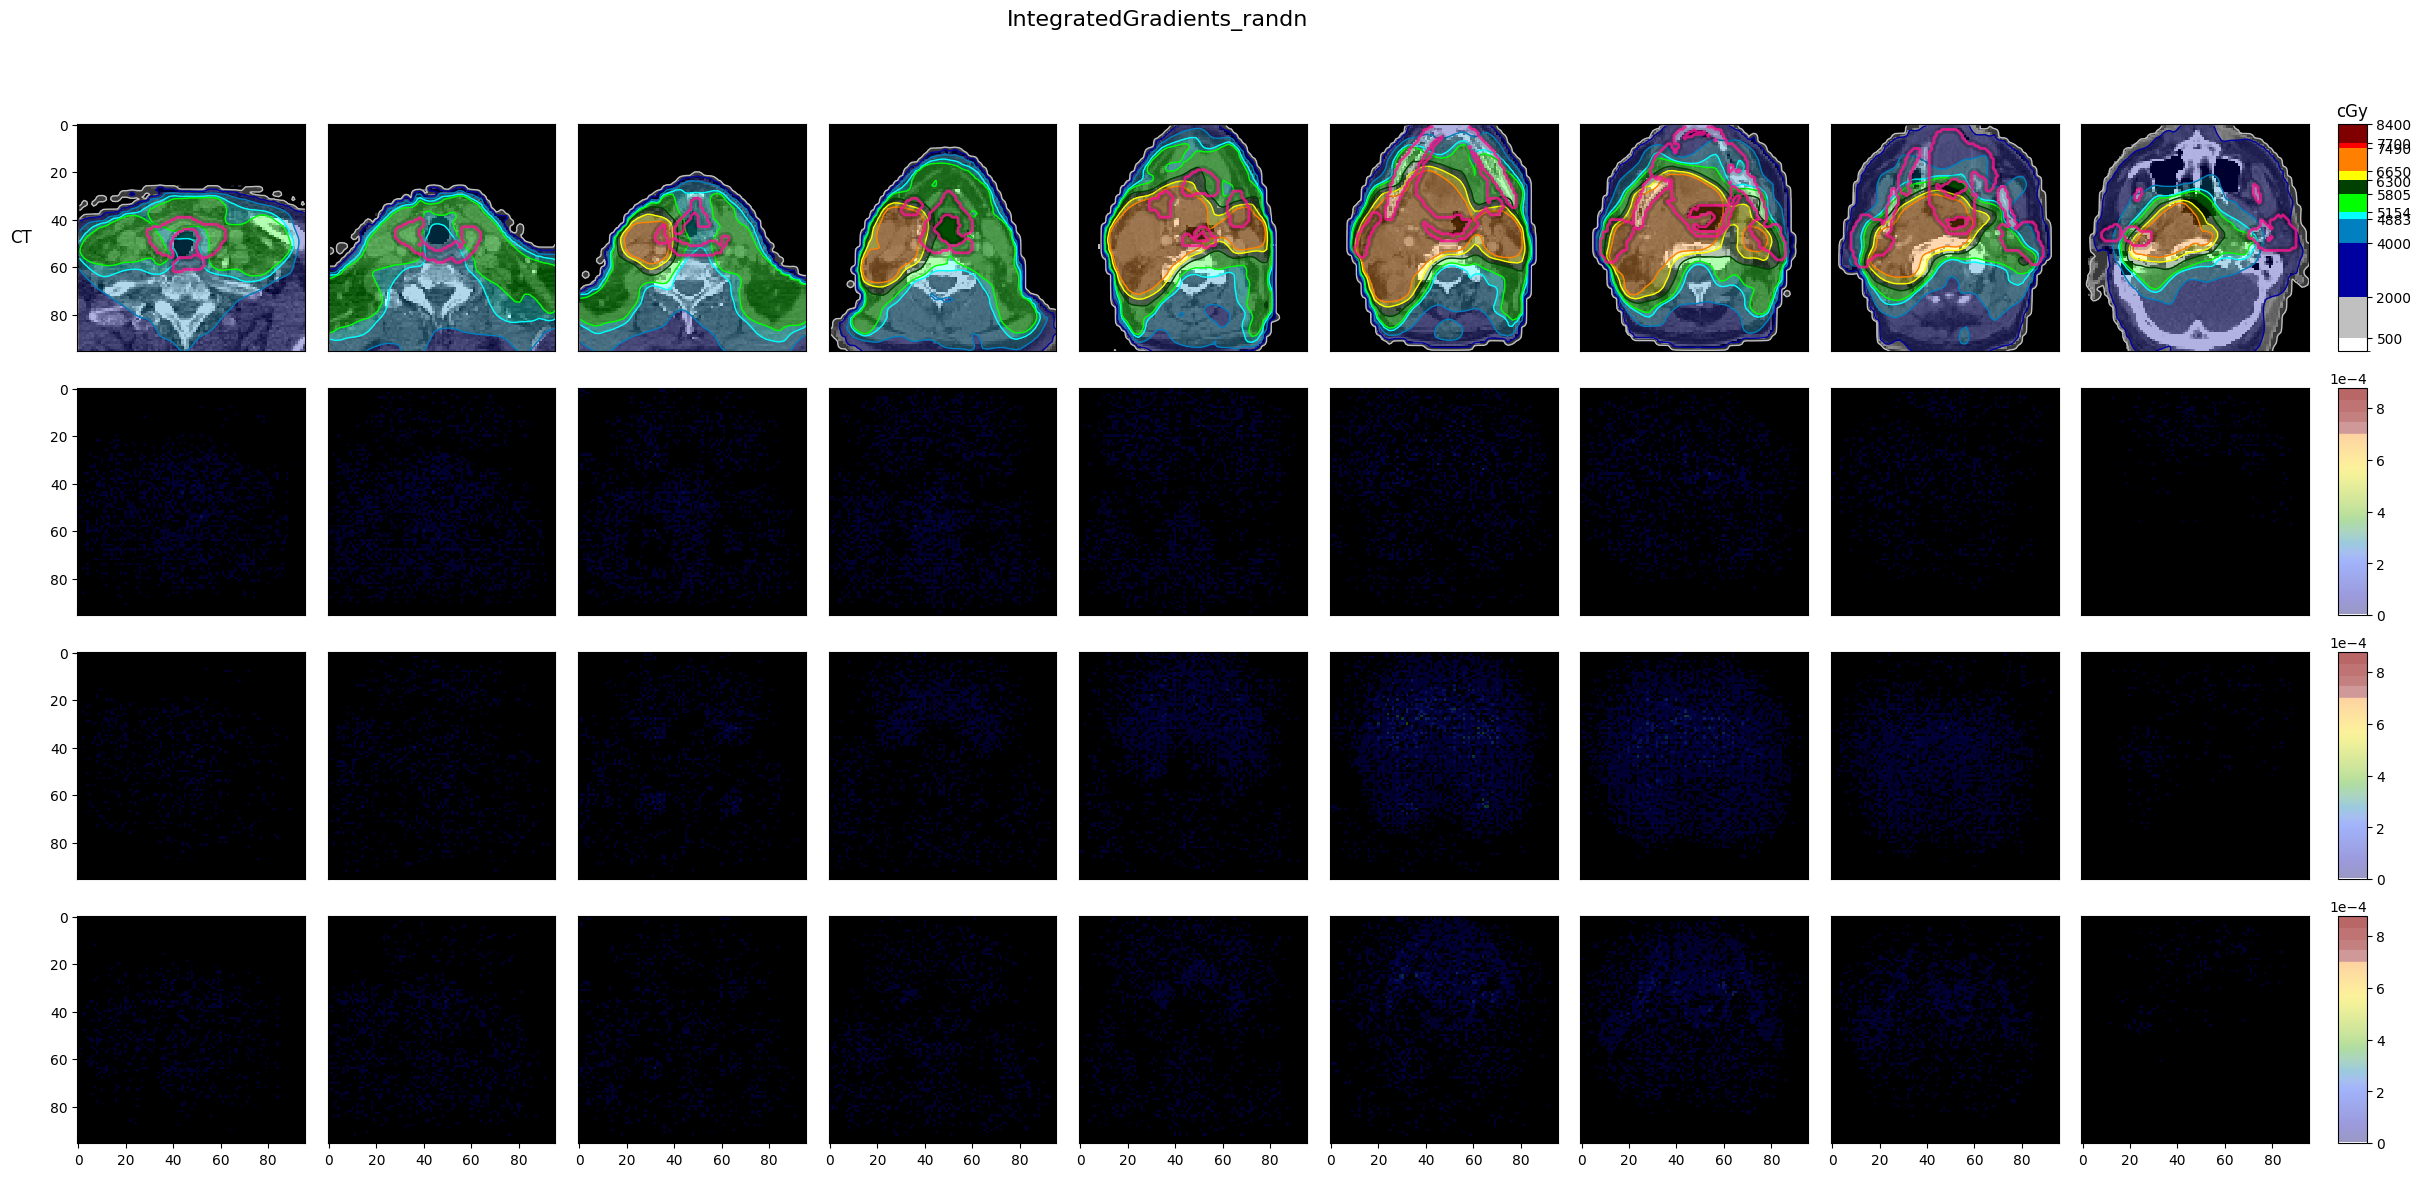

(3, 96, 96, 96)


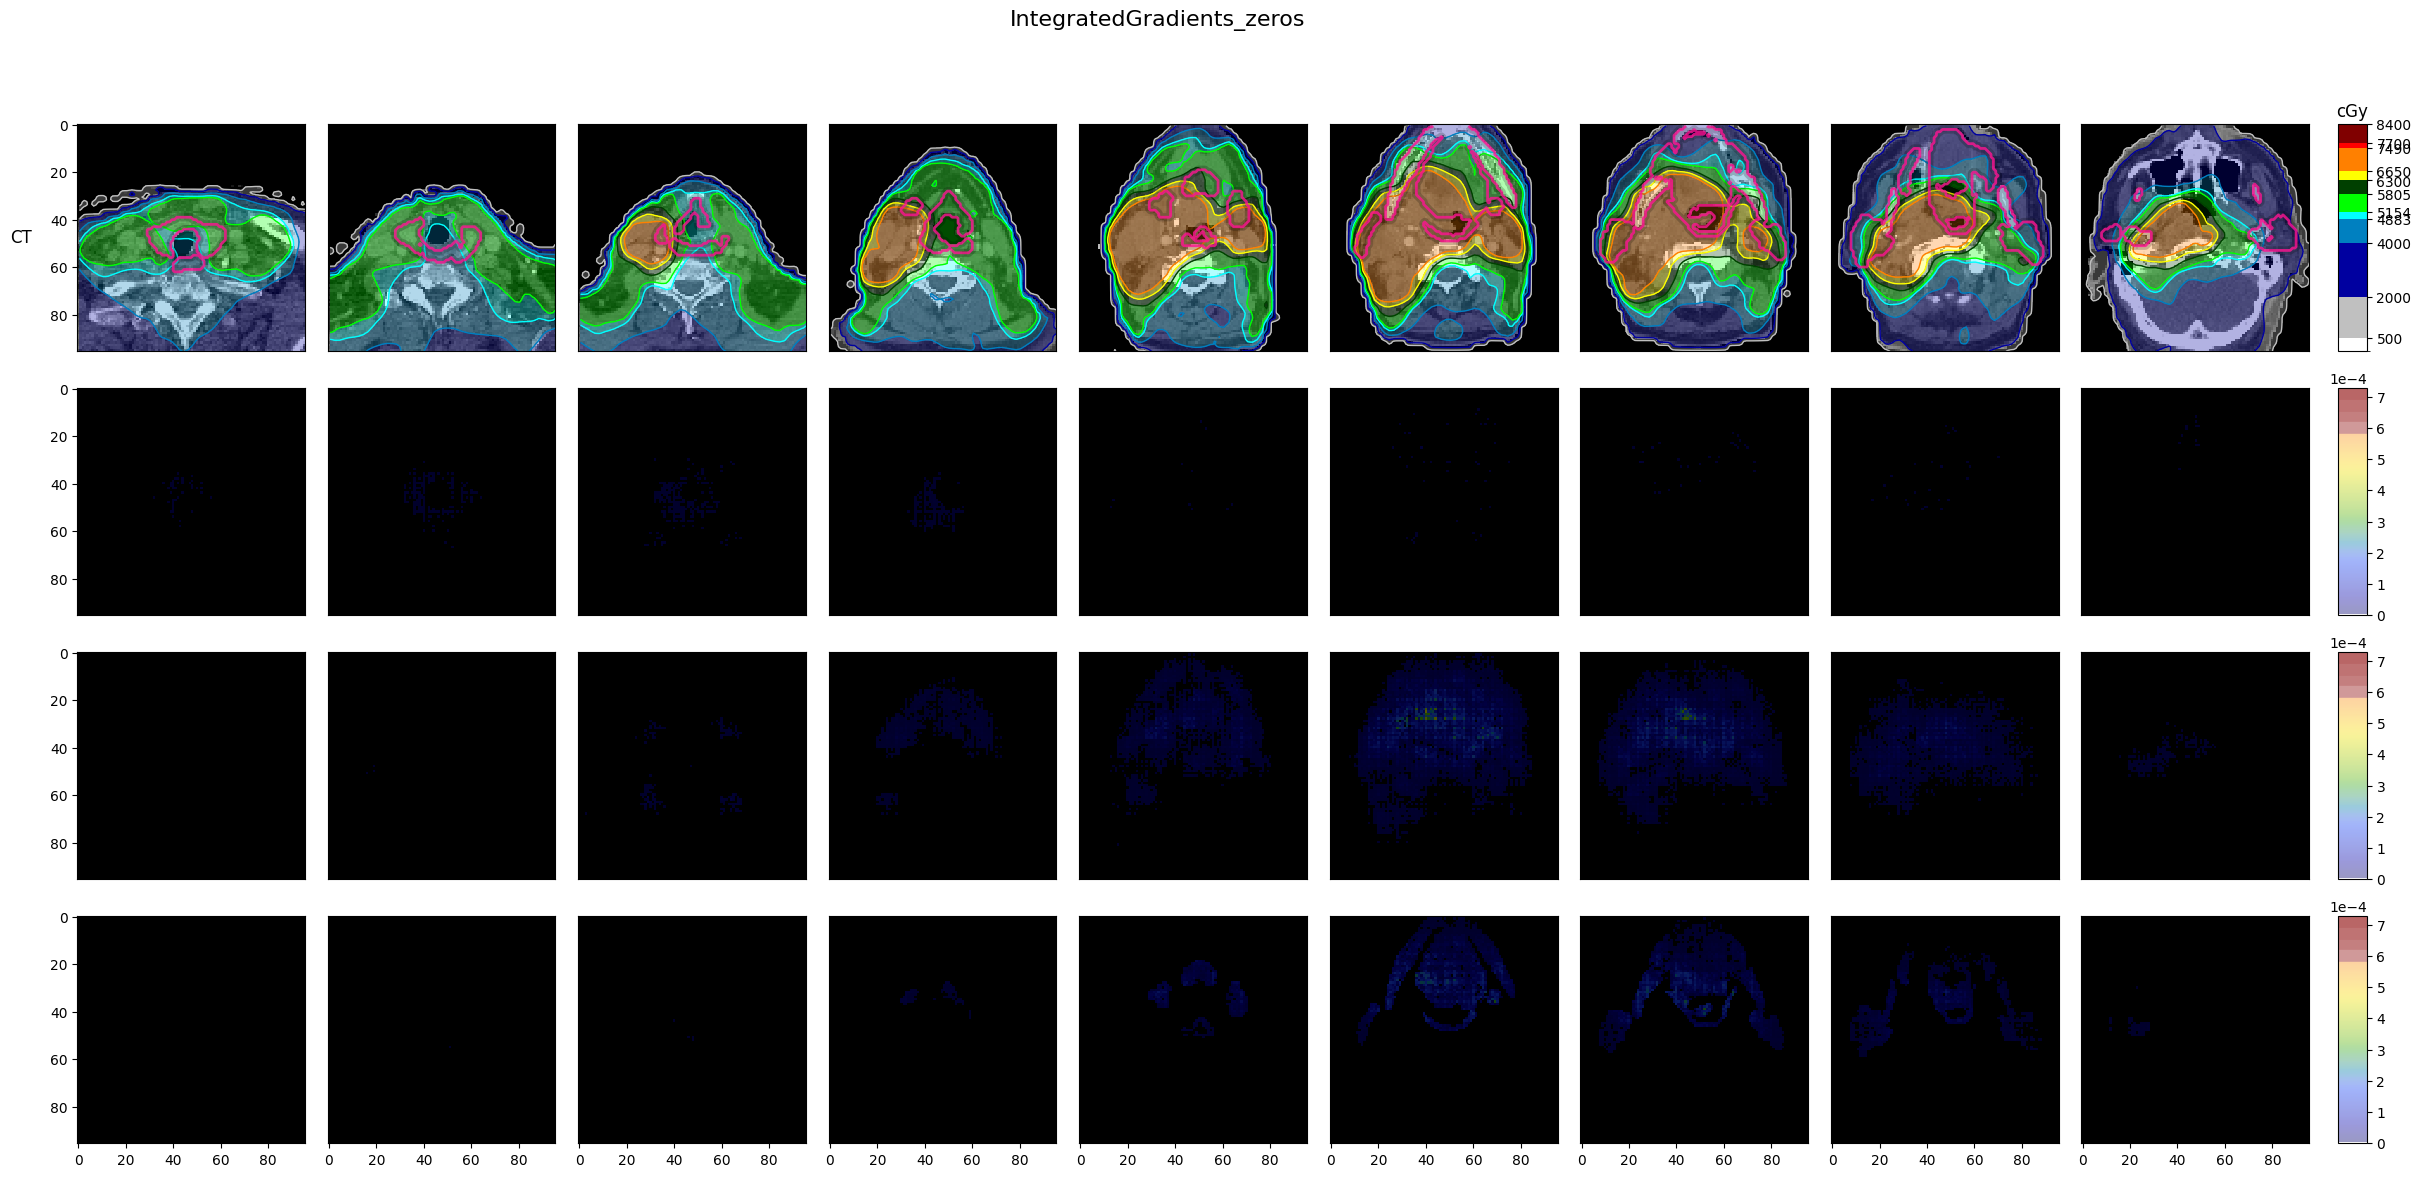

(3, 96, 96, 96)


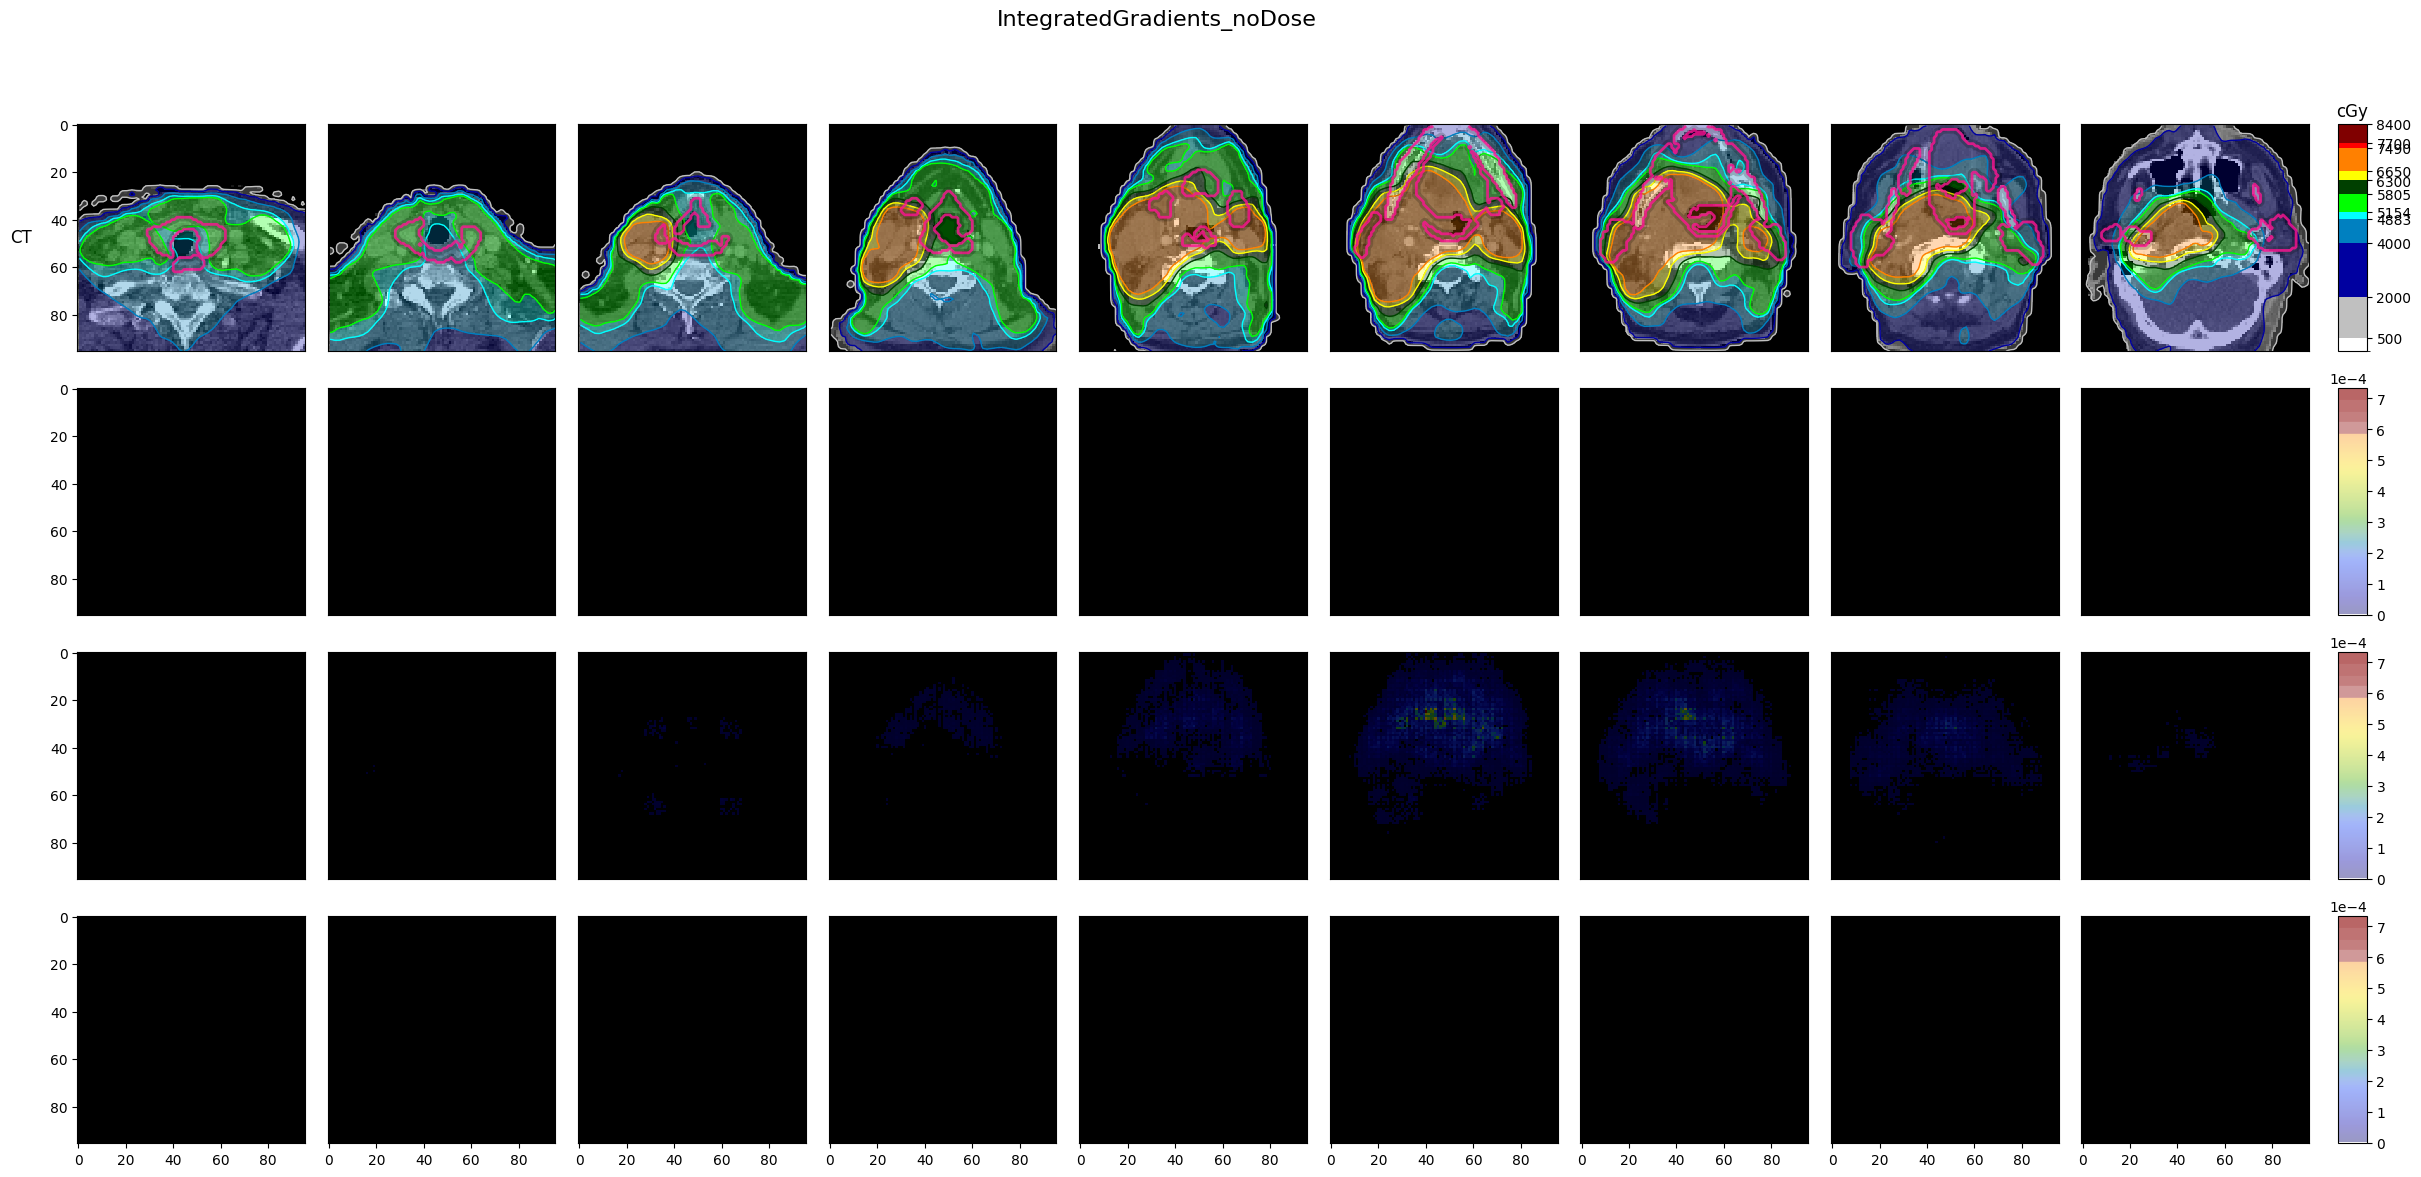

(1, 96, 96, 96)


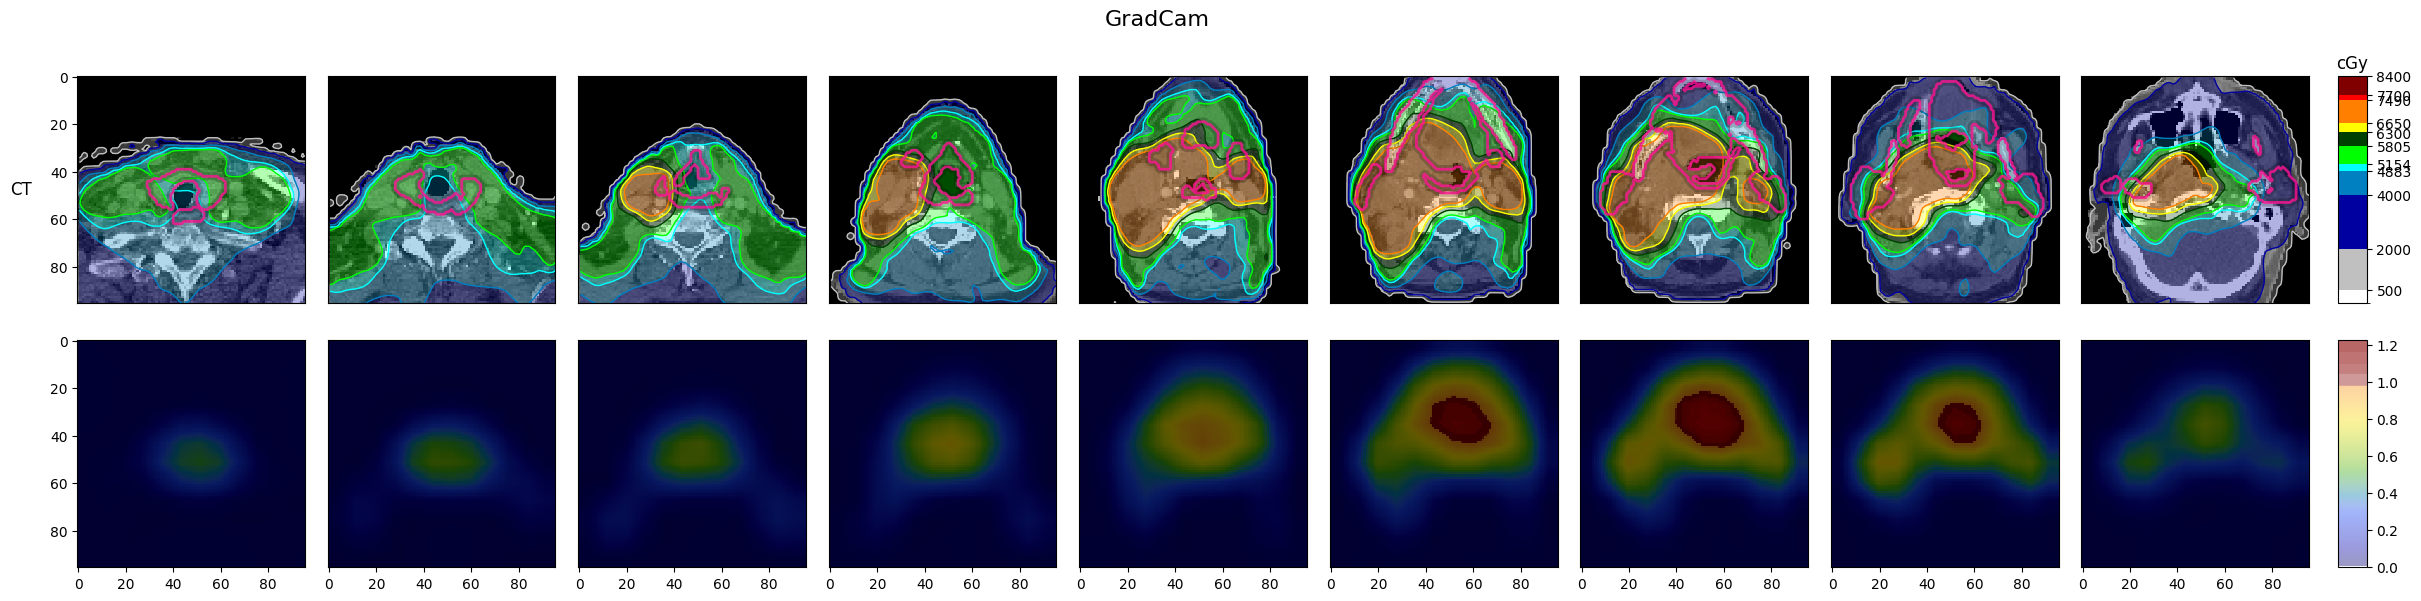

In [74]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from src.visualization.plot_slices import plot_slices
import matplotlib.pyplot as plt

CT = inputs[0][0].squeeze().cpu().detach().numpy() * 600 - 200
RTDOSE = inputs[0][1].squeeze().cpu().detach().numpy()
RTSTRUCT = inputs[0][2].squeeze().cpu().detach().numpy()



for attr_dict in attr_maps:
    plotting_dicts = [{
    "Label": "CT",
    "CT": CT,
    "RTDOSE": RTDOSE,
    "RTSTRUCT" : RTSTRUCT,

    #"Attention" : image_attention[0][0].squeeze().cpu().detach().numpy()
    }]
    
    att_image_temp = attr_dict['attention']
    print(att_image_temp.shape)
    
    for idx in range(att_image_temp.shape[0]):
        method_dict = {
        "Label": "",
        #'CT': CT,
        "Attention" : att_image_temp[idx]    }

        plotting_dicts.append(method_dict)

   # plotting_dicts.append(method_dict)

    slices = [10,20,30,40,50,60,70,80,90] 
    #slices = [71,72,73,74,75,76,77]
    fig, axes = plot_slices(row_dicts=plotting_dicts, slice_indexes=slices, title=attr_dict['method'])
    plt.show()

#fig, axes = plot_slices(row_dicts=plotting_dicts, slice_indexes=[68,69,70,71,72], title="Attention Maps")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


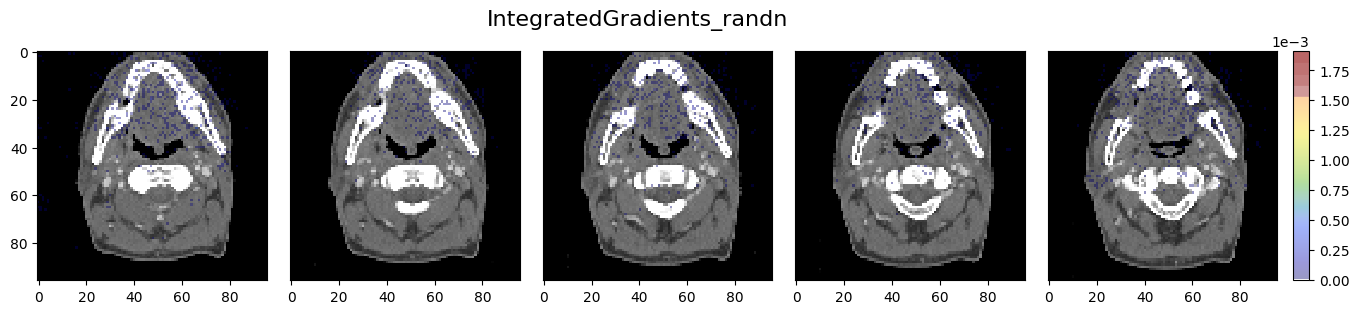

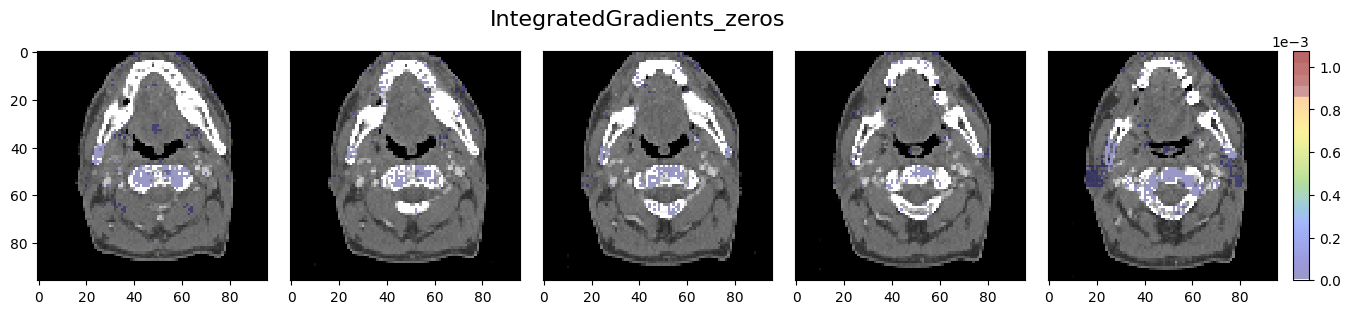

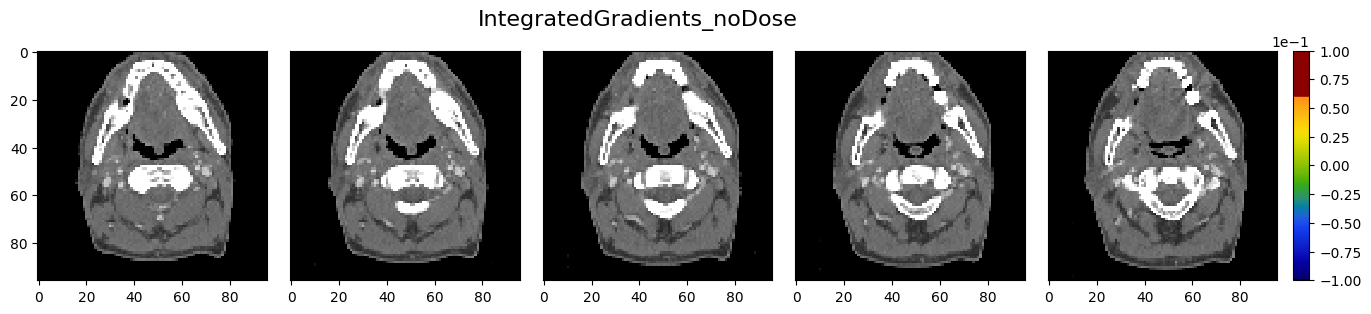

In [19]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

from src.visualization.plot_slices import plot_slices
import matplotlib.pyplot as plt

CT = inputs[0][0].squeeze().cpu().detach().numpy() * 600 - 200

plotting_dicts = [{
    "Label": "CT",
    "CT": CT,
    #"Attention" : image_attention[0][0].squeeze().cpu().detach().numpy()
}]

for attr_dict in attr_maps:
    method_dict = {
        "Label": "",
        'CT': CT,
        "Attention" : attr_dict['attention']
    }
    plotting_dicts.append(method_dict)

    slices = [68,69,70,71,72] 
    #slices = [71,72,73,74,75,76,77]
    fig, axes = plot_slices(row_dicts=[method_dict], slice_indexes=slices, title=attr_dict['method'])
    plt.show()

#fig, axes = plot_slices(row_dicts=plotting_dicts, slice_indexes=[68,69,70,71,72], title="Attention Maps")

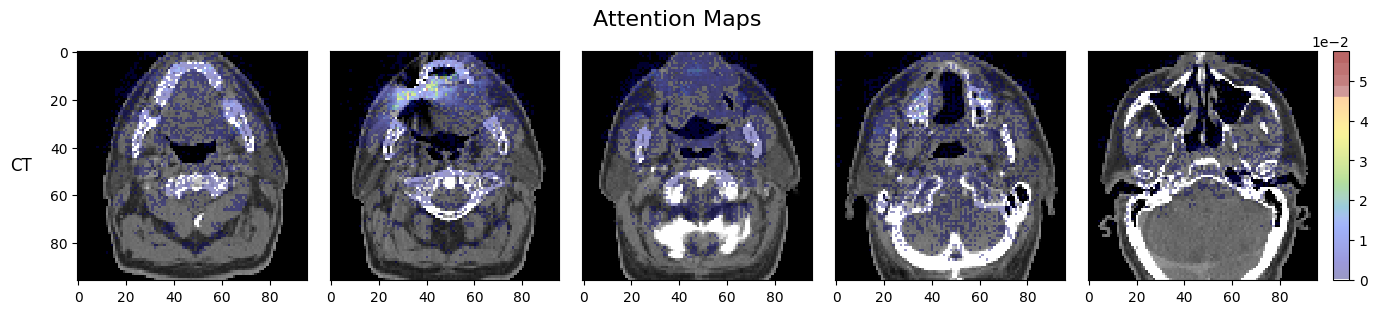

In [48]:
from src.visualization.plot_slices import plot_slices


plotting_dicts = [{
    "Label": "CT",
    "CT": (inputs[0][0].squeeze().cpu().detach().numpy() * 600) - 200,
    "Attention" : image_attention[0][0].squeeze().cpu().detach().numpy()
}]

fig, axes = plot_slices(row_dicts=plotting_dicts, slice_indexes=[65,70,75,80,90], title="Attention Maps")

In [12]:
inputs[0][0].squeeze().cpu().detach().numpy().max()

1.0

In [13]:
plt.imshow(inputs[0][0][70].squeeze().cpu().detach().numpy(), cmap='gray')

plt.colorbar()
plt.show()

NameError: name 'plt' is not defined